# 07 — Avaliação Out-of-Time (OOT)

Este notebook realiza a **avaliação final de generalização temporal** dos classificadores desenvolvidos nas etapas anteriores.

## Regra metodológica central

O conjunto **out-of-time (OOT)** somente pode ser acessado após o congelamento das decisões de desenvolvimento e da regra operacional.

Antes da execução deste notebook devem estar definidos:

- algoritmos e hiperparâmetros;
- estratégia de pré-processamento;
- tratamento da variável `Cidade`;
- regra operacional baseada em `Top-k` ou `threshold`;
- capacidade operacional ou ponto de corte correspondente.

O notebook **não retreina modelos**, **não altera hiperparâmetros** e **não redefine threshold ou Top-k** com base nos resultados do OOT.

Os resultados desta etapa representam a avaliação final da capacidade de generalização temporal.


## 1. Bibliotecas e configurações


In [22]:
from pathlib import Path
import json
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 2. Diretórios e validação da configuração congelada

O notebook somente prossegue quando existe uma configuração operacional formalmente congelada pelo notebook `06_2_consolidacao_decisao_operacional.ipynb`.


In [23]:
PROJECT_DIR = Path(r"C:\UnB\script_md")

PROCESSADOS_DIR = PROJECT_DIR / "Base de dados" / "processados"
MODELS_DIR = PROJECT_DIR / "outputs" / "modelos"
TABLES_DIR = PROJECT_DIR / "outputs" / "tabelas"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figuras"
CONFIG_DIR = PROJECT_DIR / "outputs" / "config"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = PROCESSADOS_DIR / "dataset_modelagem_preparado.csv"
CONFIG_FILE = CONFIG_DIR / "configuracao_operacional_congelada.json"

if not CONFIG_FILE.exists():
    raise FileNotFoundError(
        "Configuração operacional congelada não encontrada. "
        "Execute e finalize primeiro o notebook 06_2_consolidacao_decisao_operacional.ipynb."
    )

with CONFIG_FILE.open("r", encoding="utf-8") as f:
    configuracao = json.load(f)

if configuracao.get("regra_congelada") is not True:
    raise RuntimeError(
        "A configuração operacional não está marcada como congelada. "
        "O OOT não deve ser acessado."
    )

if configuracao.get("oot_acessado_nesta_etapa") is not False:
    raise RuntimeError(
        "A configuração não apresenta o estado esperado antes do primeiro acesso ao OOT."
    )

print("Configuração operacional validada.")
print()
print(json.dumps(configuracao, ensure_ascii=False, indent=2))


Configuração operacional validada.

{
  "estrategia_operacional": "threshold",
  "top_k_percentual": null,
  "threshold_operacional": 0.6,
  "modelos_para_oot": [
    "Regressão Logística",
    "KNN",
    "Random Forest",
    "Gradient Boosting"
  ],
  "justificativa_negocio": "Especialistas querem ter mais certeza das que serão resolvidas.",
  "data_decisao": "2026-09-24",
  "fonte_decisao": "Consulta com dois especialistas da Ouvidoria",
  "regra_congelada": true,
  "oot_acessado_nesta_etapa": false
}


### 2.1 Identificação da configuração utilizada

O hash SHA-256 abaixo permite registrar exatamente qual arquivo de configuração foi utilizado na avaliação OOT.


In [24]:
conteudo_config = CONFIG_FILE.read_bytes()

hash_config = hashlib.sha256(
    conteudo_config
).hexdigest()

print(f"SHA-256 da configuração: {hash_config}")


SHA-256 da configuração: f9d9562efadbf34d48b98190db7592a01afe8e0e896a569a600bfcdb65f1a402


## 3. Carregamento da base e isolamento do OOT


In [25]:
if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {INPUT_FILE}."
    )

df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

df_teste = (
    df[df["Amostra"] == "Teste"]
    .sort_values("AAAA_MM")
    .reset_index(drop=True)
)

df_oot = (
    df[df["Amostra"] == "OOT"]
    .sort_values("AAAA_MM")
    .reset_index(drop=True)
)

if df_oot.empty:
    raise ValueError(
        "A partição OOT está vazia."
    )

print(f"Teste/validação operacional: {len(df_teste):,} registros")
print(f"OOT: {len(df_oot):,} registros")
print()
print(f"Período OOT: {df_oot['AAAA_MM'].min()} a {df_oot['AAAA_MM'].max()}")


Teste/validação operacional: 14,027 registros
OOT: 32,072 registros

Período OOT: 2025_08 a 2026_07


## 4. Prevalência da classe positiva

Como Precision e PR-AUC são sensíveis à prevalência da classe positiva, a alteração da composição do target deve ser documentada antes da comparação das métricas.


In [26]:
TARGET = "target"

y_teste = df_teste[TARGET].astype(int).copy()
y_oot = df_oot[TARGET].astype(int).copy()

prevalencia_teste = y_teste.mean()
prevalencia_oot = y_oot.mean()

resumo_prevalencia = pd.DataFrame({
    "Período": [
        "Teste/Validação Operacional",
        "OOT"
    ],
    "Registros": [
        len(y_teste),
        len(y_oot)
    ],
    "Resolvidas": [
        int(y_teste.sum()),
        int(y_oot.sum())
    ],
    "Não Resolvidas": [
        int((1 - y_teste).sum()),
        int((1 - y_oot).sum())
    ],
    "Prevalência Resolvida": [
        prevalencia_teste,
        prevalencia_oot
    ]
})

display(
    resumo_prevalencia.round(4)
)

resumo_prevalencia.to_csv(
    TABLES_DIR / "oot_prevalencia_target.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)

print(
    f"Variação da prevalência: "
    f"{(prevalencia_oot - prevalencia_teste) * 100:.2f} p.p."
)


,Período,Registros,Resolvidas,Não Resolvidas,Prevalência Resolvida
0,Teste/Validação Operacional,14027,5395,8632,0.3846
1,OOT,32072,9149,22923,0.2853


Variação da prevalência: -9.94 p.p.


## 5. Carregamento dos pipelines congelados

Somente os modelos explicitamente registrados na configuração operacional serão avaliados.

Nenhum modelo é ajustado novamente.


In [27]:
MAPA_ARQUIVOS = {
    "Regressão Logística": MODELS_DIR / "modelo_treino_regressao_logistica.joblib",
    "KNN": MODELS_DIR / "modelo_treino_knn.joblib",
    "Random Forest": MODELS_DIR / "modelo_treino_random_forest.joblib",
    "Gradient Boosting": MODELS_DIR / "modelo_treino_gradient_boosting.joblib"
}

nomes_modelos = configuracao["modelos_para_oot"]

modelos = {}

for nome in nomes_modelos:
    if nome not in MAPA_ARQUIVOS:
        raise KeyError(
            f"Modelo não reconhecido na configuração: {nome}"
        )

    caminho = MAPA_ARQUIVOS[nome]

    if not caminho.exists():
        raise FileNotFoundError(
            f"Pipeline congelado não encontrado: {caminho}"
        )

    modelos[nome] = joblib.load(
        caminho
    )

print("Modelos carregados:")
for nome in modelos:
    print(f"- {nome}")


Modelos carregados:
- Regressão Logística
- KNN
- Random Forest
- Gradient Boosting


## 6. Identificação das features utilizadas por cada modelo

Essa etapa é necessária porque o KNN pode ter sido congelado com ou sem a variável `Cidade`.


In [28]:
PREDITORES_PADRAO = [
    "Região",
    "UF",
    "Cidade",
    "Sexo",
    "Faixa Etária",
    "Área",
    "Assunto",
    "Grupo Problema",
    "Problema",
    "Como Comprou Contratou",
    "Procurou Empresa"
]

def obter_features_modelo(modelo):
    steps = modelo.named_steps

    if "codificacao" in steps:
        transformador = steps["codificacao"]

        if hasattr(transformador, "feature_names_in_"):
            return list(
                transformador.feature_names_in_
            )

    if "preprocessamento" in steps:
        transformador = steps["preprocessamento"]

        if hasattr(transformador, "feature_names_in_"):
            return list(
                transformador.feature_names_in_
            )

    return PREDITORES_PADRAO.copy()


features_por_modelo = {
    nome: obter_features_modelo(modelo)
    for nome, modelo in modelos.items()
}

for nome, features in features_por_modelo.items():
    print(f"{nome}: {len(features)} atributos")
    print(features)
    print()


Regressão Logística: 11 atributos
['Região', 'UF', 'Cidade', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']

KNN: 10 atributos
['Região', 'UF', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']

Random Forest: 11 atributos
['Região', 'UF', 'Cidade', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']

Gradient Boosting: 11 atributos
['Região', 'UF', 'Cidade', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']



## 7. Predições probabilísticas no OOT

As probabilidades são produzidas pelos pipelines congelados.

Nenhuma informação do OOT participa do ajuste das transformações ou dos classificadores.


In [29]:
probabilidades_oot = {}

for nome, modelo in modelos.items():
    features = features_por_modelo[nome]

    X_oot = df_oot[features].copy()

    probabilidades_oot[nome] = (
        modelo.predict_proba(X_oot)[:, 1]
    )

    print(
        f"{nome}: {len(probabilidades_oot[nome]):,} "
        "probabilidades calculadas."
    )


Regressão Logística: 32,072 probabilidades calculadas.
KNN: 32,072 probabilidades calculadas.
Random Forest: 32,072 probabilidades calculadas.
Gradient Boosting: 32,072 probabilidades calculadas.


# PARTE A — Desempenho classificatório e discriminatório

## 8. Avaliação com threshold convencional de 0,50

O threshold `0,50` é mantido apenas como ponto de referência comparável ao período intermediário.

Ele não substitui a regra operacional congelada.


In [30]:
def calcular_ks(y_true, probabilidades):
    fpr, tpr, _ = roc_curve(
        y_true,
        probabilidades
    )

    return float(
        np.max(tpr - fpr)
    )


def avaliar_threshold(
    nome,
    y_true,
    probabilidades,
    threshold
):
    pred = (
        probabilidades >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred
    ).ravel()

    selecionadas = int(
        pred.sum()
    )

    cobertura = (
        selecionadas / len(pred)
        if len(pred) > 0
        else 0
    )

    precisao = precision_score(
        y_true,
        pred,
        zero_division=0
    )

    prevalencia = y_true.mean()

    lift = (
        precisao / prevalencia
        if prevalencia > 0
        else np.nan
    )

    return {
        "Modelo": nome,
        "Threshold": threshold,
        "Precisão": precisao,
        "Revocação": recall_score(
            y_true,
            pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_true,
            pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilidades
        ),
        "PR-AUC (AP)": average_precision_score(
            y_true,
            probabilidades
        ),
        "KS": calcular_ks(
            y_true,
            probabilidades
        ),
        "Selecionadas": selecionadas,
        "Cobertura": cobertura,
        "Lift": lift,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


In [31]:
resultados_oot_050 = []

for nome, prob in probabilidades_oot.items():
    resultados_oot_050.append(
        avaliar_threshold(
            nome,
            y_oot,
            prob,
            threshold=0.50
        )
    )

resultados_oot_050 = pd.DataFrame(
    resultados_oot_050
)

display(
    resultados_oot_050.round(4)
)

resultados_oot_050.to_csv(
    TABLES_DIR / "oot_metricas_threshold_050.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Threshold,Precisão,Revocação,F1-score,ROC-AUC,PR-AUC (AP),KS,Selecionadas,Cobertura,Lift,TN,FP,FN,TP
0,Regressão Logística,0.5000,0.4326,0.3979,0.4145,0.6433,0.4106,0.2174,8414,0.2623,1.5165,18149,4774,5509,3640
1,KNN,0.5000,0.3959,0.3627,0.3786,0.6090,0.3706,0.1661,8381,0.2613,1.3878,17860,5063,5831,3318
2,Random Forest,0.5000,0.4430,0.3807,0.4095,0.6481,0.4158,0.2244,7862,0.2451,1.5530,18544,4379,5666,3483
3,Gradient Boosting,0.5000,0.4375,0.3779,0.4055,0.6450,0.4111,0.2203,7902,0.2464,1.5336,18478,4445,5692,3457


## 9. Curvas ROC no OOT


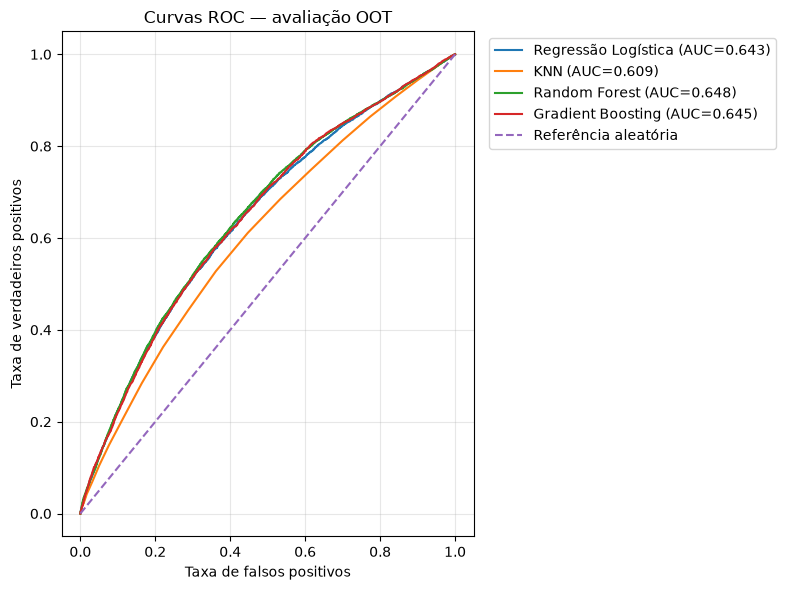

In [32]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

for nome, prob in probabilidades_oot.items():
    fpr, tpr, _ = roc_curve(
        y_oot,
        prob
    )

    auc = roc_auc_score(
        y_oot,
        prob
    )

    ax.plot(
        fpr,
        tpr,
        label=f"{nome} (AUC={auc:.3f})"
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Referência aleatória"
)

ax.set_title(
    "Curvas ROC — avaliação OOT"
)

ax.set_xlabel(
    "Taxa de falsos positivos"
)

ax.set_ylabel(
    "Taxa de verdadeiros positivos"
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "oot_curvas_roc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 10. Curvas Precisão-Revocação no OOT

A linha horizontal representa a prevalência da classe `Resolvida` no OOT.


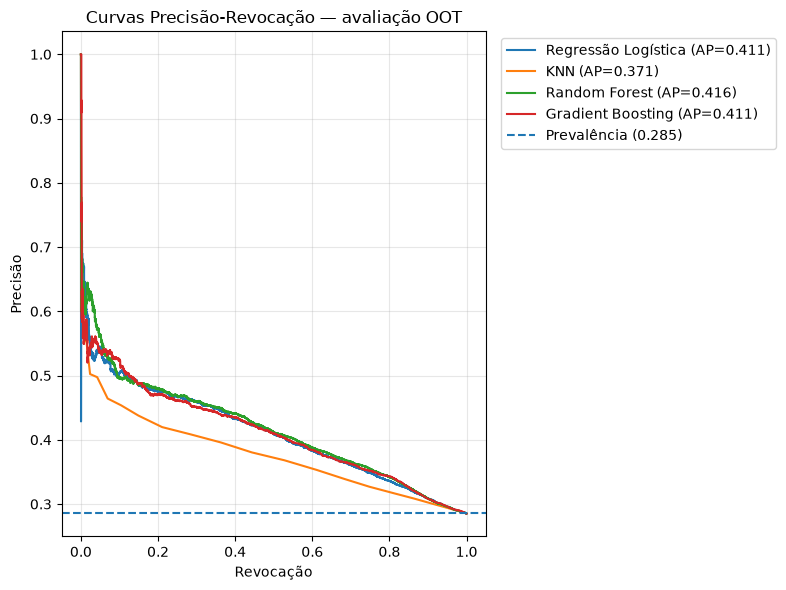

In [33]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

for nome, prob in probabilidades_oot.items():
    precision, recall, _ = precision_recall_curve(
        y_oot,
        prob
    )

    ap = average_precision_score(
        y_oot,
        prob
    )

    ax.plot(
        recall,
        precision,
        label=f"{nome} (AP={ap:.3f})"
    )

ax.axhline(
    prevalencia_oot,
    linestyle="--",
    label=f"Prevalência ({prevalencia_oot:.3f})"
)

ax.set_title(
    "Curvas Precisão-Revocação — avaliação OOT"
)

ax.set_xlabel(
    "Revocação"
)

ax.set_ylabel(
    "Precisão"
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "oot_curvas_precision_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# PARTE B — Aplicação da regra operacional congelada

## 11. Avaliação operacional

A mesma regra definida antes do acesso ao OOT será aplicada sem qualquer ajuste.

### Estratégia Top-k

Se a regra congelada for `top_k`, será selecionada exatamente a mesma proporção da população OOT, ordenada pela probabilidade prevista.

### Estratégia Threshold

Se a regra congelada for `threshold`, será aplicado exatamente o mesmo ponto de corte probabilístico.


In [34]:
ESTRATEGIA = configuracao["estrategia_operacional"]
TOP_K = configuracao.get("top_k_percentual")
THRESHOLD = configuracao.get("threshold_operacional")

print(f"Estratégia congelada: {ESTRATEGIA}")

if ESTRATEGIA == "top_k":
    print(f"Capacidade congelada: Top {TOP_K}%")

elif ESTRATEGIA == "threshold":
    print(f"Threshold congelado: {THRESHOLD}")


Estratégia congelada: threshold
Threshold congelado: 0.6


In [35]:
def avaliar_top_k(
    nome,
    y_true,
    probabilidades,
    top_percentual
):
    n = len(y_true)

    n_top = int(
        np.ceil(
            n * top_percentual / 100
        )
    )

    ordem = np.argsort(
        -probabilidades
    )

    selecionados = ordem[:n_top]

    pred = np.zeros(
        n,
        dtype=int
    )

    pred[selecionados] = 1

    y_array = np.asarray(
        y_true
    )

    tp = int(
        y_array[selecionados].sum()
    )

    precision_k = (
        tp / n_top
        if n_top > 0
        else 0
    )

    total_positivos = int(
        y_array.sum()
    )

    recall_k = (
        tp / total_positivos
        if total_positivos > 0
        else 0
    )

    lift_k = (
        precision_k / y_array.mean()
        if y_array.mean() > 0
        else np.nan
    )

    tn, fp, fn, tp_cm = confusion_matrix(
        y_array,
        pred
    ).ravel()

    return {
        "Modelo": nome,
        "Estratégia": "top_k",
        "Top (%)": top_percentual,
        "Threshold": np.nan,
        "Selecionadas": n_top,
        "Cobertura": n_top / n,
        "Precisão": precision_k,
        "Revocação": recall_k,
        "F1-score": f1_score(
            y_array,
            pred,
            zero_division=0
        ),
        "Lift": lift_k,
        "ROC-AUC": roc_auc_score(
            y_array,
            probabilidades
        ),
        "PR-AUC (AP)": average_precision_score(
            y_array,
            probabilidades
        ),
        "KS": calcular_ks(
            y_array,
            probabilidades
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp_cm)
    }


In [36]:
resultados_operacionais_oot = []

for nome, prob in probabilidades_oot.items():

    if ESTRATEGIA == "top_k":
        resultado = avaliar_top_k(
            nome,
            y_oot,
            prob,
            float(TOP_K)
        )

    elif ESTRATEGIA == "threshold":
        resultado_base = avaliar_threshold(
            nome,
            y_oot,
            prob,
            float(THRESHOLD)
        )

        resultado = {
            **resultado_base,
            "Estratégia": "threshold",
            "Top (%)": np.nan
        }

    else:
        raise ValueError(
            f"Estratégia não reconhecida: {ESTRATEGIA}"
        )

    resultados_operacionais_oot.append(
        resultado
    )

resultados_operacionais_oot = pd.DataFrame(
    resultados_operacionais_oot
)

display(
    resultados_operacionais_oot.round(4)
)

resultados_operacionais_oot.to_csv(
    TABLES_DIR / "oot_resultados_regra_operacional.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Threshold,Precisão,Revocação,F1-score,ROC-AUC,PR-AUC (AP),KS,Selecionadas,Cobertura,Lift,TN,FP,FN,TP,Estratégia,Top (%)
0,Regressão Logística,0.6000,0.4783,0.1811,0.2627,0.6433,0.4106,0.2174,3464,0.1080,1.6769,21116,1807,7492,1657,threshold,NaN
1,KNN,0.6000,0.4376,0.1492,0.2225,0.6090,0.3706,0.1661,3119,0.0972,1.5342,21169,1754,7784,1365,threshold,NaN
2,Random Forest,0.6000,0.5054,0.0929,0.1570,0.6481,0.4158,0.2244,1682,0.0524,1.7715,22091,832,8299,850,threshold,NaN
3,Gradient Boosting,0.6000,0.5039,0.1205,0.1944,0.6450,0.4111,0.2203,2187,0.0682,1.7664,21838,1085,8047,1102,threshold,NaN


# PARTE C — Generalização temporal

## 12. Comparação Teste/Validação Operacional × OOT no threshold 0,50

Esta tabela permite observar a variação temporal das principais métricas sob o mesmo ponto de corte de referência.


In [37]:
FILE_TESTE_050 = (
    TABLES_DIR /
    "modelagem_comparacao_teste.csv"
)

if not FILE_TESTE_050.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {FILE_TESTE_050}"
    )

resultados_teste_050 = pd.read_csv(
    FILE_TESTE_050,
    sep=";",
    encoding="utf-8-sig"
)

metricas_comparacao = [
    "Precisão",
    "Revocação",
    "F1-score",
    "ROC-AUC",
    "PR-AUC (AP)",
    "KS"
]

teste_base = (
    resultados_teste_050[
        resultados_teste_050["Modelo"].isin(
            nomes_modelos
        )
    ]
    .set_index("Modelo")
)

oot_base = (
    resultados_oot_050
    .set_index("Modelo")
)

linhas_delta = []

for nome in nomes_modelos:
    linha = {
        "Modelo": nome
    }

    for metrica in metricas_comparacao:
        valor_teste = float(
            teste_base.loc[nome, metrica]
        )

        valor_oot = float(
            oot_base.loc[nome, metrica]
        )

        linha[f"{metrica} Teste"] = valor_teste
        linha[f"{metrica} OOT"] = valor_oot
        linha[f"Δ {metrica}"] = (
            valor_oot - valor_teste
        )

    linhas_delta.append(
        linha
    )

comparacao_teste_oot_050 = pd.DataFrame(
    linhas_delta
)

display(
    comparacao_teste_oot_050.round(4)
)

comparacao_teste_oot_050.to_csv(
    TABLES_DIR / "oot_comparacao_teste_oot_threshold_050.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Precisão Teste,Precisão OOT,Δ Precisão,Revocação Teste,Revocação OOT,Δ Revocação,F1-score Teste,F1-score OOT,Δ F1-score,ROC-AUC Teste,ROC-AUC OOT,Δ ROC-AUC,PR-AUC (AP) Teste,PR-AUC (AP) OOT,Δ PR-AUC (AP),KS Teste,KS OOT,Δ KS
0,Regressão Logística,0.5305,0.4326,-0.0979,0.4780,0.3979,-0.0802,0.5029,0.4145,-0.0884,0.6622,0.6433,-0.0189,0.5298,0.4106,-0.1192,0.2416,0.2174,-0.0242
1,KNN,0.5032,0.3959,-0.1073,0.4458,0.3627,-0.0831,0.4728,0.3786,-0.0942,0.6302,0.6090,-0.0212,0.5006,0.3706,-0.1300,0.1807,0.1661,-0.0146
2,Random Forest,0.5371,0.4430,-0.0941,0.4602,0.3807,-0.0795,0.4957,0.4095,-0.0862,0.6662,0.6481,-0.0181,0.5410,0.4158,-0.1252,0.2387,0.2244,-0.0143
3,Gradient Boosting,0.5293,0.4375,-0.0919,0.4599,0.3779,-0.0820,0.4922,0.4055,-0.0867,0.6651,0.6450,-0.0201,0.5411,0.4111,-0.1300,0.2462,0.2203,-0.0259


## 13. Comparação da regra operacional entre período intermediário e OOT

A comparação utiliza exatamente a estratégia previamente congelada.


In [38]:
if ESTRATEGIA == "top_k":

    FILE_OPERACIONAL_TESTE = (
        TABLES_DIR /
        "operacional_precision_recall_lift_topk.csv"
    )

    teste_operacional = pd.read_csv(
        FILE_OPERACIONAL_TESTE,
        sep=";",
        encoding="utf-8-sig"
    )

    teste_operacional = teste_operacional[
        teste_operacional["Top (%)"] ==
        float(TOP_K)
    ].copy()

    teste_operacional = teste_operacional.rename(
        columns={
            "Precision@k": "Precisão",
            "Recall@k": "Revocação",
            "Lift@k": "Lift"
        }
    )

elif ESTRATEGIA == "threshold":

    FILE_OPERACIONAL_TESTE = (
        TABLES_DIR /
        "operacional_metricas_por_threshold.csv"
    )

    teste_operacional = pd.read_csv(
        FILE_OPERACIONAL_TESTE,
        sep=";",
        encoding="utf-8-sig"
    )

    teste_operacional = teste_operacional[
        teste_operacional["Threshold"].round(4) ==
        round(float(THRESHOLD), 4)
    ].copy()

    teste_operacional["Lift"] = (
        teste_operacional["Precisão"] /
        prevalencia_teste
    )

teste_operacional = (
    teste_operacional[
        teste_operacional["Modelo"].isin(
            nomes_modelos
        )
    ]
    .set_index("Modelo")
)

oot_operacional = (
    resultados_operacionais_oot
    .set_index("Modelo")
)

linhas_operacional = []

for nome in nomes_modelos:
    linha = {
        "Modelo": nome
    }

    for metrica in [
        "Precisão",
        "Revocação",
        "Lift"
    ]:
        valor_teste = float(
            teste_operacional.loc[
                nome,
                metrica
            ]
        )

        valor_oot = float(
            oot_operacional.loc[
                nome,
                metrica
            ]
        )

        linha[f"{metrica} Teste"] = valor_teste
        linha[f"{metrica} OOT"] = valor_oot
        linha[f"Δ {metrica}"] = (
            valor_oot - valor_teste
        )

    linha["Selecionadas OOT"] = int(
        oot_operacional.loc[
            nome,
            "Selecionadas"
        ]
    )

    linhas_operacional.append(
        linha
    )

comparacao_operacional = pd.DataFrame(
    linhas_operacional
)

display(
    comparacao_operacional.round(4)
)

comparacao_operacional.to_csv(
    TABLES_DIR / "oot_comparacao_regra_operacional.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Precisão Teste,Precisão OOT,Δ Precisão,Revocação Teste,Revocação OOT,Δ Revocação,Lift Teste,Lift OOT,Δ Lift,Selecionadas OOT
0,Regressão Logística,0.5830,0.4783,-0.1047,0.2532,0.1811,-0.0721,1.5158,1.6769,0.1610,3464
1,KNN,0.5596,0.4376,-0.1219,0.2221,0.1492,-0.0729,1.4548,1.5342,0.0793,3119
2,Random Forest,0.6328,0.5054,-0.1275,0.1687,0.0929,-0.0758,1.6453,1.7715,0.1262,1682
3,Gradient Boosting,0.6212,0.5039,-0.1174,0.1952,0.1205,-0.0747,1.6152,1.7664,0.1512,2187


## 14. Variação das métricas discriminatórias

ROC-AUC e KS são particularmente úteis para avaliar se a capacidade de ordenação/discriminação foi preservada mesmo diante da mudança de prevalência.

PR-AUC deve ser interpretada conjuntamente com a redução da prevalência da classe positiva.


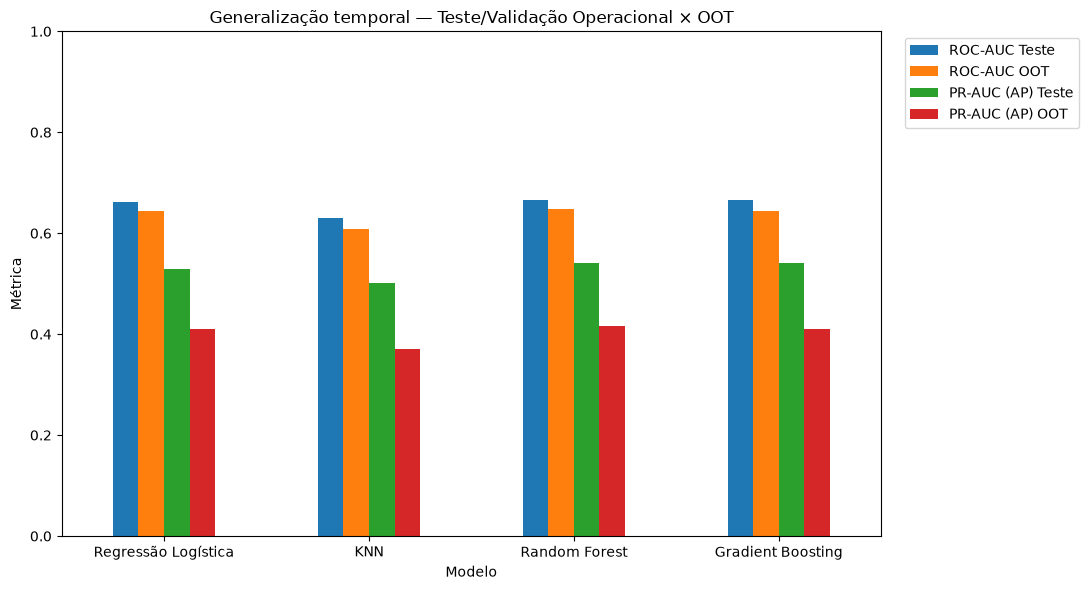

In [39]:
dados_auc = (
    comparacao_teste_oot_050[
        [
            "Modelo",
            "ROC-AUC Teste",
            "ROC-AUC OOT",
            "PR-AUC (AP) Teste",
            "PR-AUC (AP) OOT"
        ]
    ]
    .set_index("Modelo")
)

ax = dados_auc.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title(
    "Generalização temporal — Teste/Validação Operacional × OOT"
)

ax.set_xlabel(
    "Modelo"
)

ax.set_ylabel(
    "Métrica"
)

ax.set_ylim(0, 1)

ax.tick_params(
    axis="x",
    rotation=0
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "oot_generalizacao_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# PARTE D — Síntese para Resultados e Discussões

## 15. Síntese automática da generalização temporal

O texto abaixo descreve os resultados sem realizar qualquer novo ajuste ou seleção de hiperparâmetros.


In [40]:
print(
    f"A prevalência da classe Resolvida diminuiu de "
    f"{prevalencia_teste * 100:.2f}% no período de teste/validação operacional "
    f"para {prevalencia_oot * 100:.2f}% no OOT, correspondendo a uma variação de "
    f"{(prevalencia_oot - prevalencia_teste) * 100:.2f} pontos percentuais."
)

print()

for _, linha in comparacao_teste_oot_050.iterrows():
    print(
        f"{linha['Modelo']}: "
        f"ROC-AUC {linha['ROC-AUC Teste']:.4f} → {linha['ROC-AUC OOT']:.4f} "
        f"(Δ={linha['Δ ROC-AUC']:+.4f}); "
        f"PR-AUC {linha['PR-AUC (AP) Teste']:.4f} → {linha['PR-AUC (AP) OOT']:.4f} "
        f"(Δ={linha['Δ PR-AUC (AP)']:+.4f}); "
        f"KS {linha['KS Teste']:.4f} → {linha['KS OOT']:.4f} "
        f"(Δ={linha['Δ KS']:+.4f})."
    )

print()
print("REGRA OPERACIONAL CONGELADA")
print()

for _, linha in comparacao_operacional.iterrows():
    print(
        f"{linha['Modelo']}: "
        f"Precisão {linha['Precisão Teste']:.4f} → {linha['Precisão OOT']:.4f}; "
        f"Revocação {linha['Revocação Teste']:.4f} → {linha['Revocação OOT']:.4f}; "
        f"Lift {linha['Lift Teste']:.4f} → {linha['Lift OOT']:.4f}; "
        f"{int(linha['Selecionadas OOT']):,} reclamações selecionadas no OOT."
    )

print()
print(
    "Os resultados OOT devem ser utilizados exclusivamente como avaliação final "
    "da generalização temporal. Nenhuma decisão de desenvolvimento deve ser alterada "
    "em função do desempenho observado nesta amostra."
)


A prevalência da classe Resolvida diminuiu de 38.46% no período de teste/validação operacional para 28.53% no OOT, correspondendo a uma variação de -9.94 pontos percentuais.

Regressão Logística: ROC-AUC 0.6622 → 0.6433 (Δ=-0.0189); PR-AUC 0.5298 → 0.4106 (Δ=-0.1192); KS 0.2416 → 0.2174 (Δ=-0.0242).
KNN: ROC-AUC 0.6302 → 0.6090 (Δ=-0.0212); PR-AUC 0.5006 → 0.3706 (Δ=-0.1300); KS 0.1807 → 0.1661 (Δ=-0.0146).
Random Forest: ROC-AUC 0.6662 → 0.6481 (Δ=-0.0181); PR-AUC 0.5410 → 0.4158 (Δ=-0.1252); KS 0.2387 → 0.2244 (Δ=-0.0143).
Gradient Boosting: ROC-AUC 0.6651 → 0.6450 (Δ=-0.0201); PR-AUC 0.5411 → 0.4111 (Δ=-0.1300); KS 0.2462 → 0.2203 (Δ=-0.0259).

REGRA OPERACIONAL CONGELADA

Regressão Logística: Precisão 0.5830 → 0.4783; Revocação 0.2532 → 0.1811; Lift 1.5158 → 1.6769; 3,464 reclamações selecionadas no OOT.
KNN: Precisão 0.5596 → 0.4376; Revocação 0.2221 → 0.1492; Lift 1.4548 → 1.5342; 3,119 reclamações selecionadas no OOT.
Random Forest: Precisão 0.6328 → 0.5054; Revocação 0.1687 → 0

## 16. Registro da avaliação OOT

Será salvo um arquivo separado documentando:

- hash da configuração congelada;
- regra operacional utilizada;
- modelos avaliados;
- período OOT;
- quantidade de observações.

O arquivo de configuração original não será alterado.


In [41]:
registro_oot = {
    "config_sha256": hash_config,
    "estrategia_operacional": ESTRATEGIA,
    "top_k_percentual": TOP_K,
    "threshold_operacional": THRESHOLD,
    "modelos_avaliados": nomes_modelos,
    "periodo_oot_inicio": str(
        df_oot["AAAA_MM"].min()
    ),
    "periodo_oot_fim": str(
        df_oot["AAAA_MM"].max()
    ),
    "n_oot": int(
        len(df_oot)
    ),
    "prevalencia_resolvida_oot": float(
        prevalencia_oot
    ),
    "avaliacao_final_executada": True
}

REGISTRO_FILE = (
    CONFIG_DIR /
    "registro_avaliacao_oot.json"
)

with REGISTRO_FILE.open(
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        registro_oot,
        f,
        ensure_ascii=False,
        indent=2
    )

print(
    f"Registro salvo em: {REGISTRO_FILE}"
)


Registro salvo em: C:\UnB\script_md\outputs\config\registro_avaliacao_oot.json


## 17. Próximas etapas

Após a avaliação OOT, as próximas dimensões do estudo poderão ser examinadas sem alterar os modelos:

1. **calibração**, incluindo Brier Score e curvas de calibração;
2. **estabilidade populacional**, incluindo PSI entre treino, período intermediário e OOT;
3. **interpretabilidade**, utilizando coeficientes, importâncias e/ou SHAP conforme o algoritmo;
4. síntese multidimensional dos modelos;
5. eventual aplicação do modelo selecionado às reclamações `Não Avaliada`.

A avaliação OOT não deve ser utilizada para reabrir tuning, pré-processamento ou seleção de variáveis.
